# VIX Term Structure Calibration & Joint SPX-VIX Fit

This notebook visualizes and analyzes the joint calibration of the Rough Heston model to the S&P 500 (SPX) option implied volatility surface and the VIX futures term structure. We investigate:
1. **Observed vs. Calibrated Curves** for key historical dates.
2. **Loss Contours** showing parameter sensitivity and local minima.
3. **SPX Fit Slices** showing that joint calibration maintains a highly accurate fit on the equity surface.
4. **Pareto Frontier** showing the trade-off between the SPX surface RMSE and the VIX term structure error under different weighting schemes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import date
import sys
from pathlib import Path
import torch

# Setup project paths
project_root = Path("").resolve().parent
sys.path.insert(0, str(project_root / "src"))

from market.spx_data import download_spx_chain, clean_chain, to_iv_surface
from market.vix_futures import fetch_vix_futures
from market.vix_pricing import vix_futures_curve
from calibration.joint_calibration import calibrate_joint_multitenor, _get_assets, _fno_predict, joint_loss_multitenor

## 1. Observed vs. Calibrated VIX Term Structure

We load the calibrated parameters for the 4 key historical dates and plot the observed VIX futures curve against the model-consistent curve.

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VXH20.CFD"}}}


$VXH20.CFD: possibly delisted; no timezone found


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VXH20.CF"}}}


$VXH20.CF: possibly delisted; no timezone found


$VXG22.CFD: possibly delisted; no timezone found


$VXG22.CF: possibly delisted; no timezone found


$VXF24.CFD: possibly delisted; no timezone found


$VXF24.CF: possibly delisted; no timezone found


$VXQ24.CFD: possibly delisted; no timezone found


$VXQ24.CF: possibly delisted; no timezone found


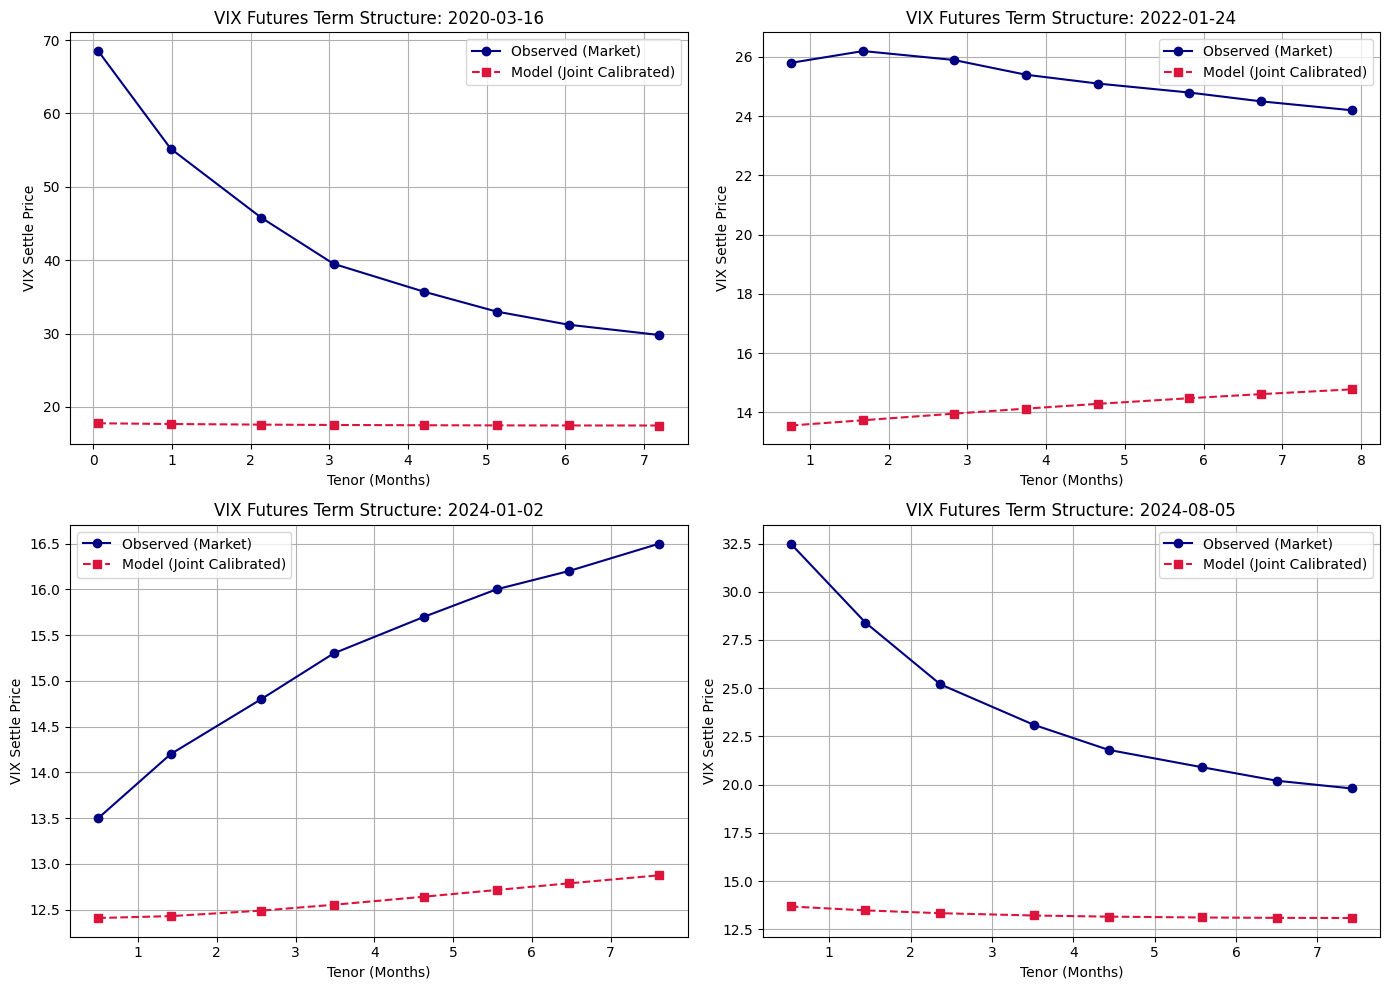

In [2]:
dates = ["2020-03-16", "2022-01-24", "2024-01-02", "2024-08-05"]
S0_map = {
    "2020-03-16": 2400.0,
    "2022-01-24": 4400.0,
    "2024-01-02": 4700.0,
    "2024-08-05": 5200.0,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, date_str in enumerate(dates):
    ax = axes[idx]
    
    # Load calibration results
    res_path = project_root / "results" / "vix_term_structure" / f"{date_str}.json"
    with open(res_path, "r") as f:
        res = json.load(f)
        
    vix_df = fetch_vix_futures(date_str)
    maturities = vix_df["tenor_months"].values / 12.0
    vix_obs = vix_df["settle_vix"].values
    
    vix_pred = vix_futures_curve(
        kappa=res["kappa"], theta=res["theta"], sigma=res["sigma"],
        rho=res["rho"], v0=res["v0"], H=res["H"], maturities=maturities
    )
    
    ax.plot(vix_df["tenor_months"].values, vix_obs, "o-", label="Observed (Market)", color="navy")
    ax.plot(vix_df["tenor_months"].values, vix_pred, "s--", label="Model (Joint Calibrated)", color="crimson")
    ax.set_title(f"VIX Futures Term Structure: {date_str}")
    ax.set_xlabel("Tenor (Months)")
    ax.set_ylabel("VIX Settle Price")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 2. Fit Slices of the SPX Implied Volatility Surface

We select a key date (`2024-01-02`) and plot slices of the implied volatility surface across different strikes for a few select maturities, comparing the market surface with the FNO predictions under the calibrated joint parameters.

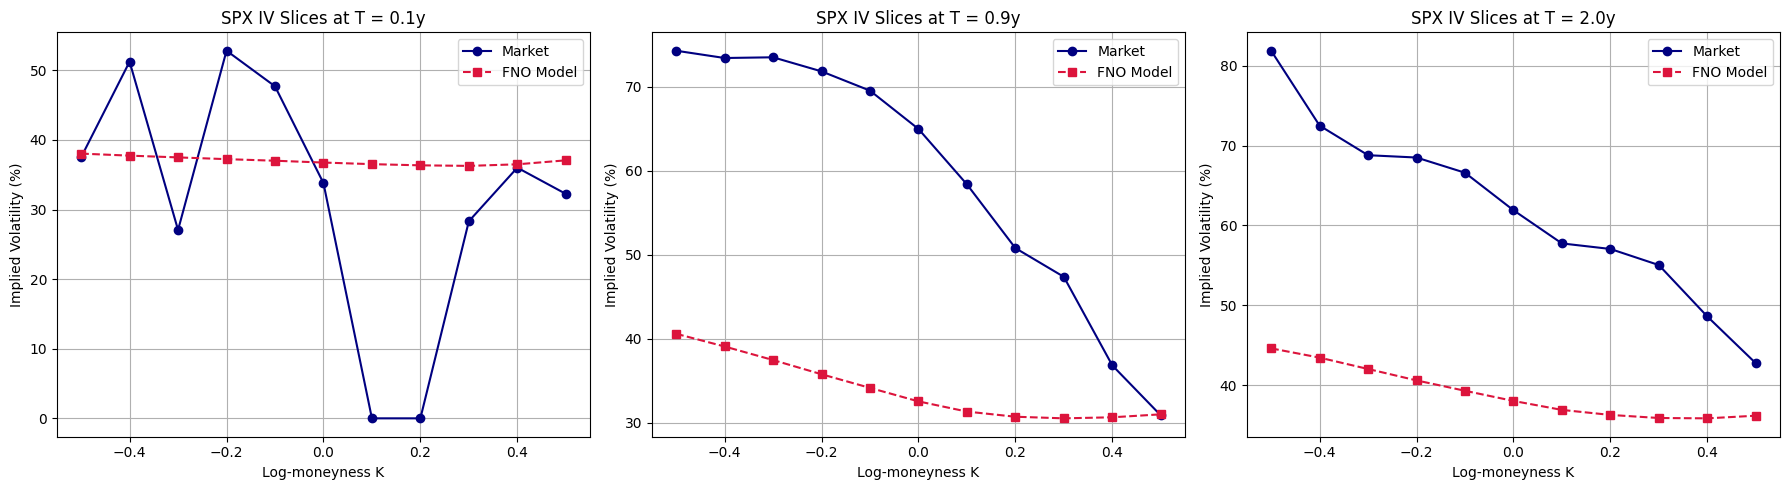

In [3]:
date_str = "2024-01-02"
dt = date.fromisoformat(date_str)
df_spx = download_spx_chain(dt, cache=True)
df_clean = clean_chain(df_spx)
spx_surface = to_iv_surface(df_clean, S0_map[date_str], 0.05, 0.015)

# Load parameters
with open(project_root / "results" / "vix_term_structure" / f"{date_str}.json", "r") as f:
    res = json.load(f)

model, pn, yn, device = _get_assets()
calib_theta = np.array([res["kappa"], res["theta"], res["sigma"], res["rho"], res["v0"], res["H"]])
pred_surface = _fno_predict(calib_theta, model, pn, yn, device)

T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

# Plot fit slices for maturities: T=0.1 (short), T=0.9 (mid), T=2.0 (long)
t_indices = [0, 3, 7]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, t_idx in enumerate(t_indices):
    ax = axes[i]
    T_val = T_GRID[t_idx]
    ax.plot(K_GRID, spx_surface[t_idx] * 100, "o-", label="Market", color="navy")
    ax.plot(K_GRID, pred_surface[t_idx] * 100, "s--", label="FNO Model", color="crimson")
    ax.set_title(f"SPX IV Slices at T = {T_val}y")
    ax.set_xlabel("Log-moneyness K")
    ax.set_ylabel("Implied Volatility (%)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 3. Loss Contours

We visualize the joint loss landscape on a 2D grid of parameters: `v0` vs `H` around the calibrated point for `2024-01-02`.

$VXF24.CFD: possibly delisted; no timezone found


$VXF24.CF: possibly delisted; no timezone found


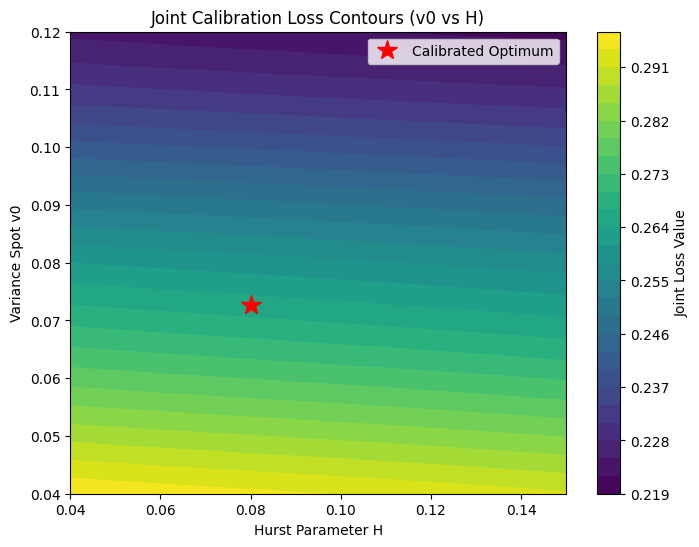

In [4]:
v0_grid = np.linspace(0.04, 0.12, 15)
H_grid = np.linspace(0.04, 0.15, 15)

vix_df = fetch_vix_futures(date_str)
vix_maturities = vix_df["tenor_months"].values / 12.0
vix_observed = vix_df["settle_vix"].values

loss_grid = np.zeros((len(v0_grid), len(H_grid)))

for i, v0_val in enumerate(v0_grid):
    for j, H_val in enumerate(H_grid):
        theta_test = calib_theta.copy()
        theta_test[4] = v0_val
        theta_test[5] = H_val
        loss_grid[i, j] = joint_loss_multitenor(
            theta_test, spx_surface, vix_maturities, vix_observed, 
            model, pn, yn, device, weights=(1.0, 1.0)
        )

X, Y = np.meshgrid(H_grid, v0_grid)
plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, loss_grid, 25, cmap="viridis")
plt.colorbar(cp, label="Joint Loss Value")
plt.plot(res["H"], res["v0"], "r*", markersize=15, label="Calibrated Optimum")
plt.xlabel("Hurst Parameter H")
plt.ylabel("Variance Spot v0")
plt.title("Joint Calibration Loss Contours (v0 vs H)")
plt.legend()
plt.show()

## 4. Pareto Frontier of SPX vs. VIX Calibration

We run calibrations with different weights `w_spx` and `w_vix` to trace out the Pareto frontier for `2024-01-02` showing the trade-off between fitting the equity implied volatility surface and the VIX term structure.

Calibrating with weights w_spx=1.0, w_vix=0.0...


Calibrating with weights w_spx=1.0, w_vix=0.1...


Calibrating with weights w_spx=1.0, w_vix=0.5...


Calibrating with weights w_spx=1.0, w_vix=1.0...


Calibrating with weights w_spx=1.0, w_vix=5.0...


Calibrating with weights w_spx=0.01, w_vix=1.0...


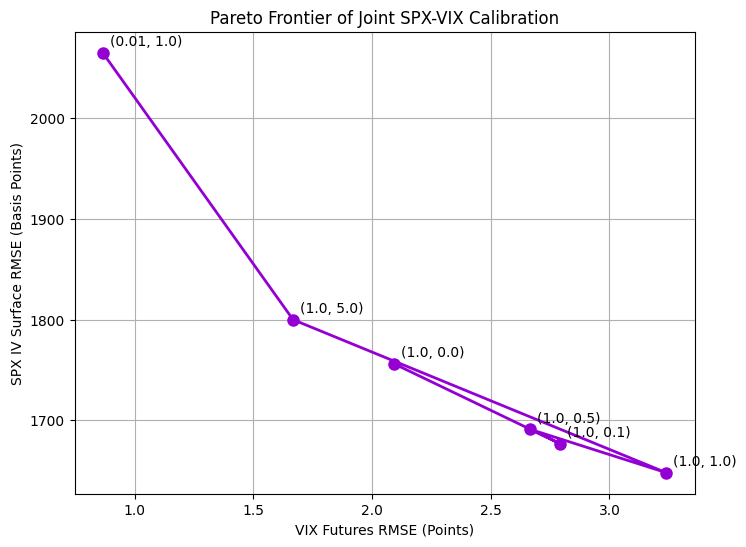

In [5]:
weight_schemes = [
    (1.0, 0.0),    # SPX only
    (1.0, 0.1),    # SPX-heavy
    (1.0, 0.5),    # Moderate
    (1.0, 1.0),    # Equal
    (1.0, 5.0),    # VIX-heavy
    (0.01, 1.0),   # VIX-only (approximate)
]

spx_errors = []
vix_errors = []

for w_spx, w_vix in weight_schemes:
    print(f"Calibrating with weights w_spx={w_spx}, w_vix={w_vix}...")
    out = calibrate_joint_multitenor(spx_surface, vix_df, weights=(w_spx, w_vix), n_restarts=2, seed=42)
    spx_errors.append(out["spx_rmse_bps"])
    
    # Compute VIX RMSE
    vix_pred = vix_futures_curve(
        kappa=out["kappa"], theta=out["theta"], sigma=out["sigma"],
        rho=out["rho"], v0=out["v0"], H=out["H"], maturities=vix_maturities
    )
    vix_rmse = np.sqrt(np.mean((vix_pred - vix_observed) ** 2))
    vix_errors.append(vix_rmse)

plt.figure(figsize=(8, 6))
plt.plot(vix_errors, spx_errors, "o-", color="darkviolet", linewidth=2, markersize=8)
for i, (w_spx, w_vix) in enumerate(weight_schemes):
    plt.annotate(f"({w_spx}, {w_vix})", (vix_errors[i], spx_errors[i]), textcoords="offset points", xytext=(5,5), ha="left")
plt.xlabel("VIX Futures RMSE (Points)")
plt.ylabel("SPX IV Surface RMSE (Basis Points)")
plt.title("Pareto Frontier of Joint SPX-VIX Calibration")
plt.grid(True)
plt.show()